To do: \
Change the length until the correct tension appears. \
Compare the predicted location with the measured location.

Import libraries

In [1]:
import csv
import numpy as np
from Stiffnesses import k_fl, k_Al
from TensegritySim import Node, Connection, Tensegrity, TensegritySolver
from TensegritySim import ConnectionNonlinear, NonlinProps
import matplotlib.pyplot as plt

Read in the old data

In [2]:
xs_old = []
ys_old = []
with open("Tables/Array 18 v1.csv", "r", newline="") as file1:
    reader = csv.DictReader(file1)
    for row in reader:
        xs_old.append(float(row["Node 6 x"])) # mm
        ys_old.append(float(row["Node 6 y"])) # mm

Read in the new data

In [3]:
xs_new = []
ys_new = []
with open("Tables/Array 18 v2.csv", "r", newline="") as file2:
    reader = csv.DictReader(file2)
    for row in reader:
        xs_new.append(float(row["Node 6 x"])) # mm
        ys_new.append(float(row["Node 6 y"])) # mm

Read in the stress-strain data

In [4]:
Strain = []
Stress = []
with open("Tables/Array 18 Stress Strain.csv", "r", newline="") as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        Strain.append(float(row["Strain"])) # %
        Stress.append(float(row["Stress (MPa)"])) # MPa or N/mm^2
Strain = np.array(Strain)
Stress = np.array(Stress)

Create the tensegrity object

In [ ]:
string = Connection.ConnectionType.STRING
bar = Connection.ConnectionType.BAR

node1 = Node(name="A", position=np.array([0., 0.])) # mm
node2 = Node(name="B", position=np.array([68.12, 0.])) # mm
node3 = Node(name="C", position=np.array([68.12, 68.12])) # mm
node4 = Node(name="D", position=np.array([0., 68.12])) # mm
node5 = Node(name="E", position=np.array([136.24, 0.])) # mm
node6 = Node(name="F", position=np.array([136.24, 68.12])) # mm
nodes = [node1, node2, node3, node4, node5, node6]

connection1 = Connection(nodes=[node1, node2, node5, node6], connection_type=string, stiffness=k_fl, name="control_string")
connection2 = ConnectionNonlinear(nodes=[node2, node3], connection_type=string, material_properties=NonlinProps(strain=Strain, stress=Stress))
connection3 = ConnectionNonlinear(nodes=[node3, node4], connection_type=string, material_properties=NonlinProps(strain=Strain, stress=Stress))
connection4 = ConnectionNonlinear(nodes=[node4, node1], connection_type=string, material_properties=NonlinProps(strain=Strain, stress=Stress))
connection5 = ConnectionNonlinear(nodes=[node3, node6], connection_type=string, material_properties=NonlinProps(strain=Strain, stress=Stress))
connection6 = Connection(nodes=[node1, node3], connection_type=bar, stiffness=k_Al)
connection7 = Connection(nodes=[node2, node4], connection_type=bar, stiffness=k_Al)
connection8 = Connection(nodes=[node2, node6], connection_type=bar, stiffness=k_Al)
connection9 = Connection(nodes=[node5, node3], connection_type=bar, stiffness=k_Al)
connections = [connection1,
               connection2, connection3, connection4, connection5,
               connection6, connection7, connection8, connection9]

pins = {"A": [True, True],
        "B": [False, True],
        "C": [False, False],
        "D": [False, False],
        "E": [False, False],
        "F": [False, False]}

controls = [connection1]

tensegrity_system = Tensegrity(nodes, connections, pins, controls)
solver = TensegritySolver(tensegrity_system)
solver.solve()

delta_ls = [-3.3, -3.2]
tensions = [0.]
for delta in delta_ls:
    tensegrity_system.change_control_lengths(delta)
    solver.solve()
    tensions.append(connection1.force)

Masses = np.arange(0., 701., 50) # Masses in grams
Forces = Masses / 1000. * 9.8 # Convert to Newtons
print(Forces)
print(tensions)

[0.   0.49 0.98 1.47 1.96 2.45 2.94 3.43 3.92 4.41 4.9  5.39 5.88 6.37
 6.86]
[0.0, 0.48403427751382083, 0.9169709260464981, 0.9175395530131488, 0.9181084598926833]


Plot the data

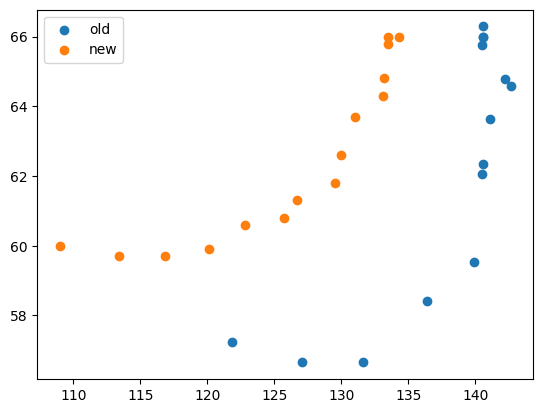

In [6]:
plt.scatter(xs_old, ys_old, label="old")
plt.scatter(xs_new, ys_new, label="new")
plt.legend()
plt.show()
plt.close()